# Libraries

In [55]:
import pandas as pd
import numpy as np
import os
import json
from typing import Tuple, Dict, List
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from scipy.stats import spearmanr
import seaborn as sns

In [56]:
# Directories
ROOT_DIR = os.path.abspath("")
DATA_DIR = os.path.join(ROOT_DIR, "data/")

# Data Management

In [57]:
# Importation des données
x_train = pd.read_csv(DATA_DIR + "X_train.csv")
y_train = pd.read_csv(DATA_DIR + "y_train.csv")
x_test = pd.read_csv(DATA_DIR + "X_test.csv")

In [58]:
# On récupère les colonnes de X_train classées
with open(DATA_DIR + "facteurs.json") as f:
    columns_dict = json.load(f)

## Premier Pas

In [59]:
# Affichage du nombre de valeurs manquantes par colonne
x = x_train.copy()
print(f"Train set observations: {len(x)}\n")
for key in columns_dict.keys():
    print(f"{key}:\n{x[columns_dict[key]].isna().sum()}\n")

print(f"Train set observations (without NaN): {len(x.dropna(how='any'))}")

Train set observations: 1494

to_keep:
ID         0
DAY_ID     0
COUNTRY    0
dtype: int64

production:
DE_GAS        0
FR_GAS        0
DE_COAL       0
FR_COAL       0
DE_HYDRO      0
FR_HYDRO      0
DE_NUCLEAR    0
FR_NUCLEAR    0
DE_SOLAR      0
FR_SOLAR      0
DE_WINDPOW    0
FR_WINDPOW    0
DE_LIGNITE    0
dtype: int64

consumption:
DE_CONSUMPTION      0
FR_CONSUMPTION      0
DE_RESIDUAL_LOAD    0
FR_RESIDUAL_LOAD    0
dtype: int64

exchange:
DE_FR_EXCHANGE     25
FR_DE_EXCHANGE     25
DE_NET_EXPORT     124
FR_NET_EXPORT      70
DE_NET_IMPORT     124
FR_NET_IMPORT      70
dtype: int64

weather:
DE_RAIN    94
FR_RAIN    94
DE_WIND    94
FR_WIND    94
DE_TEMP    94
FR_TEMP    94
dtype: int64

commodity_price:
GAS_RET       0
COAL_RET      0
CARBON_RET    0
dtype: int64

Train set observations (without NaN): 1276


In [60]:
# Statistiques descriptives
pd.DataFrame(x_train).describe()

,ID,DAY_ID,DE_CONSUMPTION,FR_CONSUMPTION,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,FR_NET_EXPORT,DE_NET_IMPORT,FR_NET_IMPORT,...,FR_RESIDUAL_LOAD,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP,GAS_RET,COAL_RET,CARBON_RET
count,1494.000000,1494.000000,1494.000000,1494.000000,1469.000000,1469.000000,1370.000000,1424.000000,1370.000000,1424.000000,...,1494.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1494.000000,1494.000000,1494.000000
mean,1072.759036,591.861446,0.427442,-0.020032,-0.145508,0.145508,-0.256332,-0.072643,0.256332,0.072643,...,-0.153688,-0.037831,0.019357,0.109480,0.123099,0.009451,0.008404,0.058126,0.061724,0.080510
std,618.013179,345.065043,0.673412,0.918995,0.970226,0.970226,0.957443,1.075830,0.957443,1.075830,...,0.896325,0.984233,1.051781,1.056243,1.054692,0.972394,1.003356,1.097768,1.033853,1.098624
min,0.000000,0.000000,-2.265563,-1.462350,-2.856874,-2.634831,-2.464849,-2.825331,-2.279619,-1.951516,...,-1.678936,-2.128531,-1.726420,-1.880419,-1.895319,-4.549638,-5.787097,-5.349463,-5.706442,-4.281790
25%,540.250000,292.250000,-0.037421,-0.716771,-0.875213,-0.638867,-0.977214,-0.851500,-0.452252,-0.794843,...,-0.802333,-0.642117,-0.503927,-0.652135,-0.672614,-0.618259,-0.647948,-0.624238,-0.458038,-0.522968
50%,1077.500000,591.000000,0.357061,-0.394166,-0.164287,0.164287,-0.306899,0.099455,0.306899,-0.099455,...,-0.460160,-0.274901,-0.228147,-0.261571,-0.229031,-0.026306,-0.020889,0.008493,0.063312,0.054056
75%,1597.500000,885.750000,0.922057,0.650533,0.638867,0.875213,0.452252,0.794843,0.977214,0.851500,...,0.382191,0.335237,0.154351,0.635050,0.824781,0.651832,0.699131,0.676415,0.641446,0.599094
max,2146.000000,1215.000000,2.033851,3.300640,2.634831,2.856874,2.279619,1.951516,2.464849,2.825331,...,2.918326,7.756118,9.473201,5.085624,4.965028,2.858758,2.817239,5.674778,3.746576,5.471818


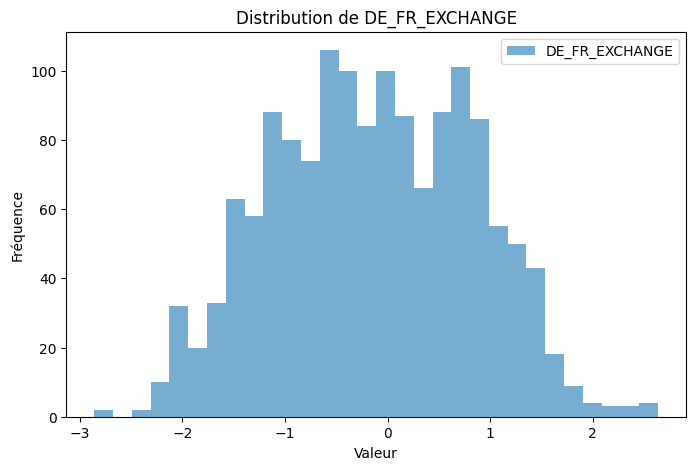

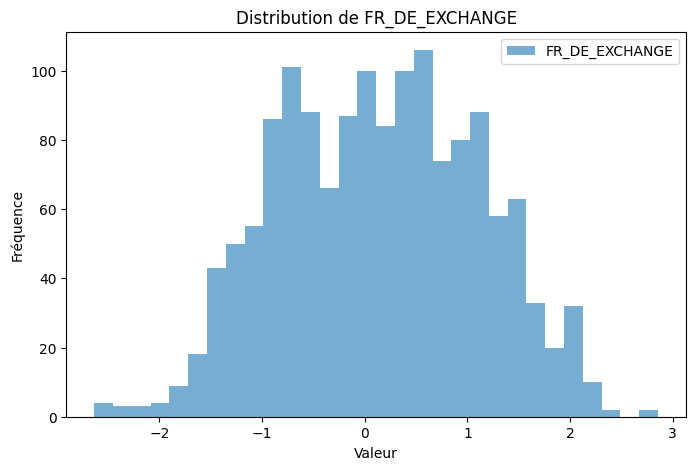

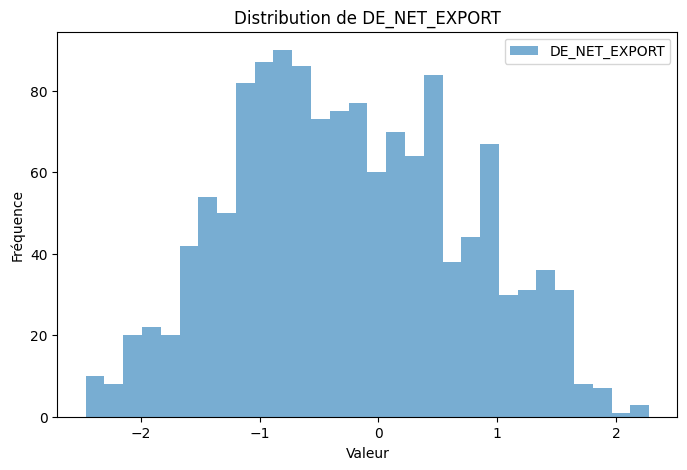

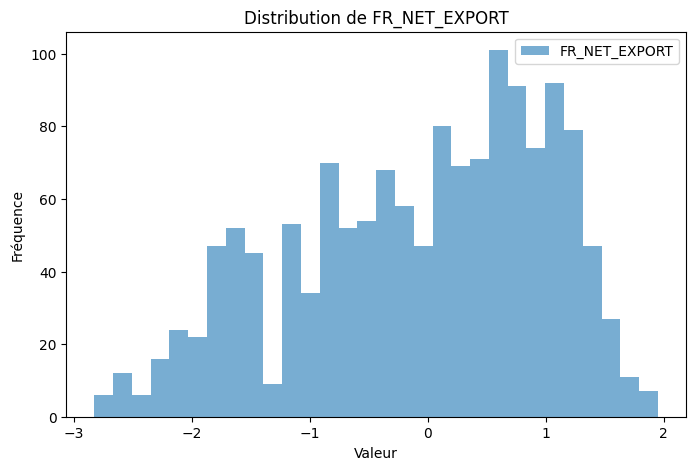

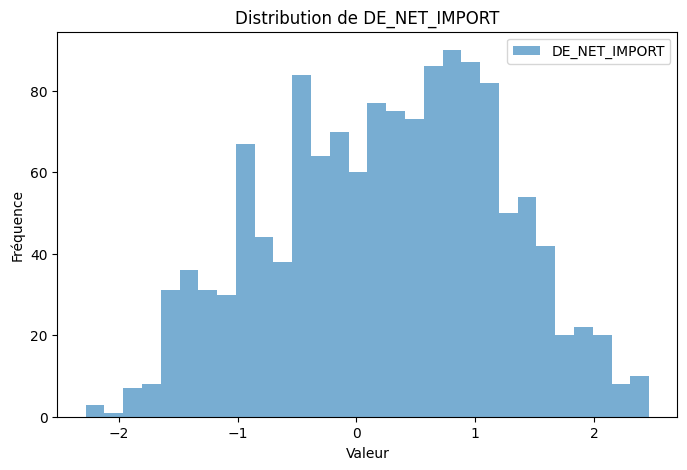

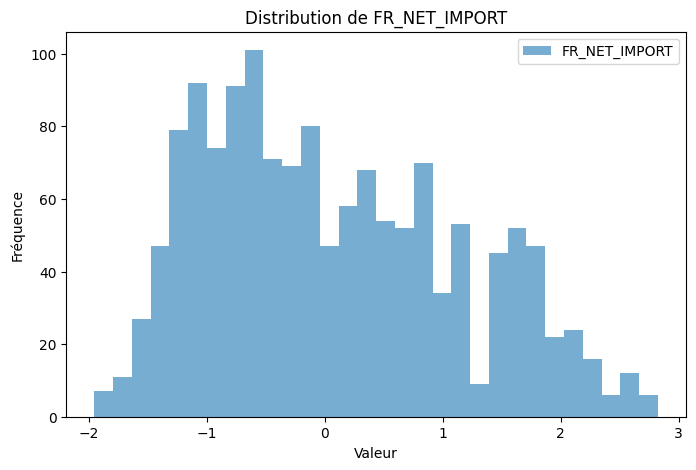

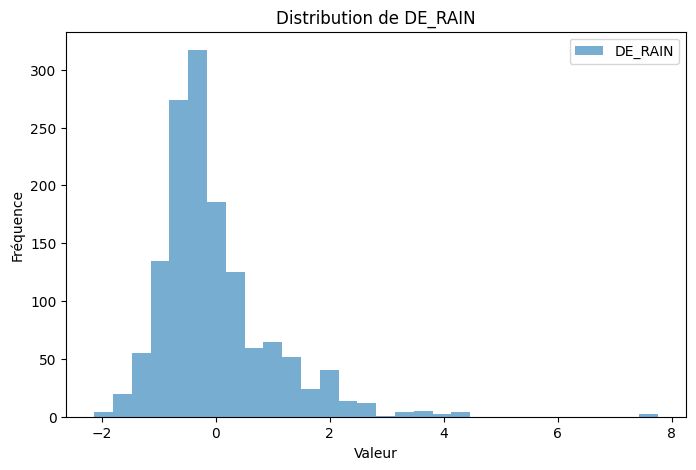

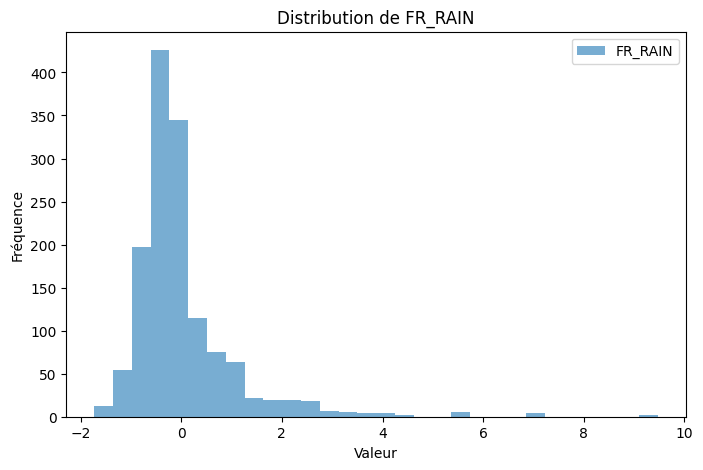

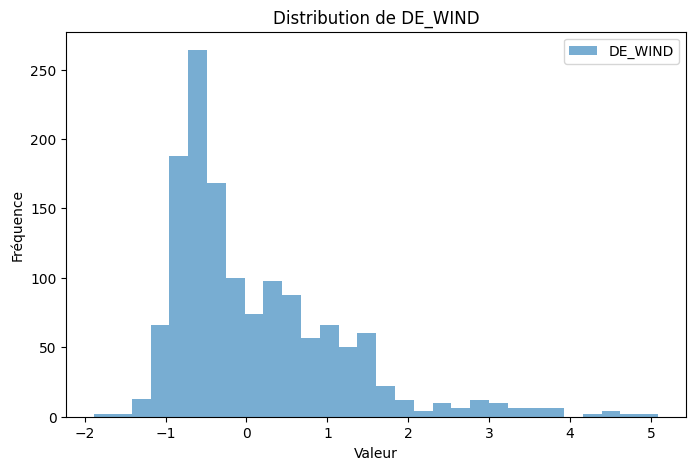

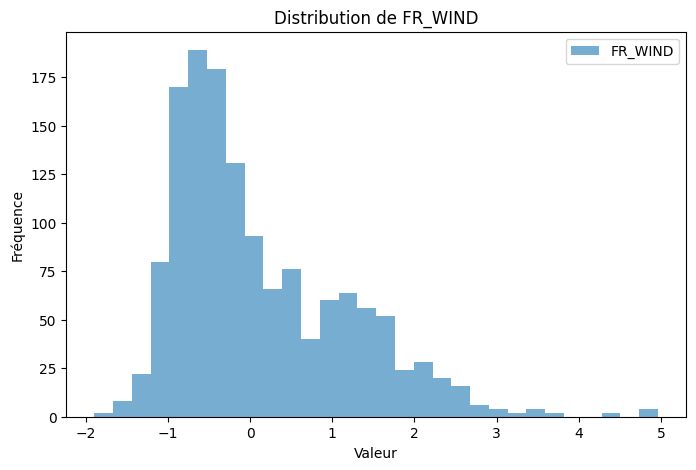

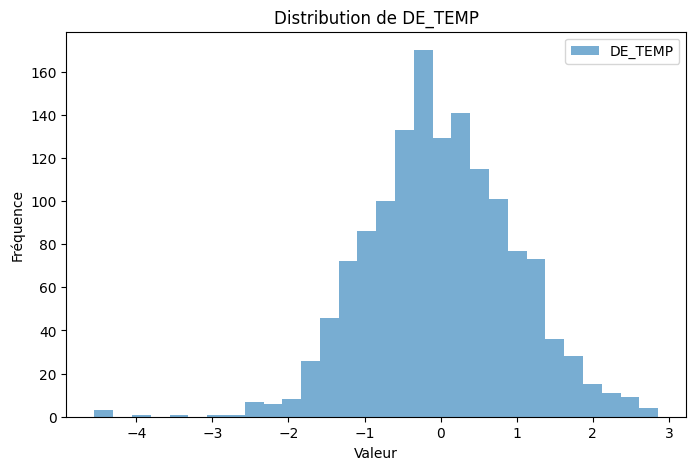

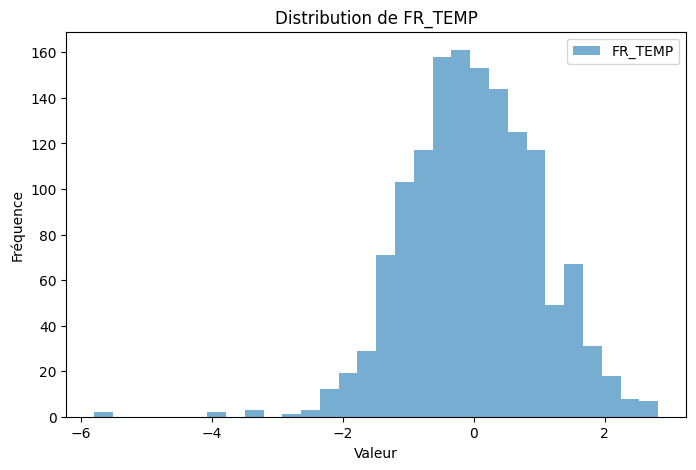

In [61]:
col_na = [col for col in x_train.columns if x_train[col].isna().any()]

for col in col_na:
    x = x_train[col]

    plt.figure(figsize=(8, 5))
    plt.hist(x, bins=30, alpha=0.6, label=col)
    plt.xlabel("Valeur")
    plt.ylabel("Fréquence")
    plt.title(f"Distribution de {col}")
    plt.legend()
    plt.show()


## Gestion des NaN

In [62]:
# Fonction de remplissage des valeurs manquantes avec KNN
def fit_knn(df_train, df_test) -> Tuple[pd.DataFrame, pd.DataFrame]:

    # Colonnes numériques sans identifiants
    feature_cols = [c for c in df_train.columns if c not in columns_dict['to_keep']]

    # On teste des k différents pour le KNN
    scores = {}
    for k in range(3,16):
        pipe = Pipeline([
            ('imputer', KNNImputer(n_neighbors=k)),
            ('model', Ridge())
        ])
        score = cross_val_score(pipe, df_train[feature_cols], y_train,
                                cv=5, scoring='r2').mean()
        scores[k] = score
    print(f"Scores par k : {scores}")

    # On choisit le k avec le plus haut score de cross-validation
    best_k = max(scores, key=lambda k: scores[k])
    print(f"Meilleur k : {best_k} (score={scores[best_k]:.4f})")

    # Fit avec le k optimal
    imputer = KNNImputer(n_neighbors=best_k)

    df_train_imputed = pd.DataFrame(
        imputer.fit_transform(df_train[feature_cols]),
        columns=feature_cols,
        index=df_train.index
    )

    df_test_imputed = pd.DataFrame(
         imputer.transform(df_test[feature_cols]),
         columns=feature_cols,
         index=df_test.index
    )

    return df_train_imputed, df_test_imputed

# Remplissage des valeurs manquantes sur train et test
def custom_fill_na(df_train: pd.DataFrame, df_test: pd.DataFrame, how='mean'):
    
    df_train.sort_values('ID', inplace=True)
    df_test.sort_values('ID', inplace=True)

    feature_cols = [c for c in df_train.columns if c not in columns_dict['to_keep']]
    
    # Apply filling method
    if how == 'mean':
        df_fill_train = df_train[feature_cols].copy()

        df_fill_train.fillna(df_fill_train.mean(), inplace=True)

        final_df = pd.concat([df_train[columns_dict['to_keep']], df_fill_train], axis=1)

        return final_df, df_test 
    
    elif how == 'med':
        df_fill_train = df_train[feature_cols].copy()

        df_fill_train.fillna(df_fill_train.median(), inplace=True)

        final_df = pd.concat([df_train[columns_dict['to_keep']], df_fill_train], axis=1)

        return final_df, df_test
    
    elif how == 'knn':
        return fit_knn(df_train.copy(), df_test.copy())


In [63]:
x_train_filled, x_test_filled = custom_fill_na(x_train, x_test, how='med')

## Ajout de features de façon économique

In [64]:
# Ajout des features sur les deux datasets
for X in [x_train_filled, x_test_filled]:

    # Besoin de production pour satisfaire la demande après production renouvelable et importation/exportation
    X['FR_BALANCE'] = X['FR_RESIDUAL_LOAD'] + X['FR_NET_IMPORT']
    X['DE_BALANCE'] = X['DE_RESIDUAL_LOAD'] + X['DE_NET_IMPORT']

    GAS_EFFICIENCY = 0.5 # il faut 0,5 MWh de gaz pour produire 1 MWh d'électricité
    GAS_EMISSION_FACTOR = 0.4 # émission de 0,4 tonne de CO2 par MWh de gaz brûlé 

    COAL_EFFICIENCY = 0.5 # il faut 0,5 tonne de charbon pour produire 1 MWh d'électricité
    COAL_EMISSION_FACTOR = 1 # émission d'une tonne de CO2 par tonne de charbon brûlée

    X['MARGINAL_GAS'] = GAS_EFFICIENCY * X['GAS_RET'] + GAS_EMISSION_FACTOR * X['CARBON_RET']
    X['MARGINAL_COAL'] = COAL_EFFICIENCY * X['COAL_RET'] + COAL_EMISSION_FACTOR * X['CARBON_RET']


    X["DE_GAS_IMPACT"] = X["DE_GAS"] * X["MARGINAL_GAS"]
    X["FR_GAS_IMPACT"] = X["FR_GAS"] * X["MARGINAL_GAS"]

    X["DE_COAL_IMPACT"] = (X["DE_COAL"] + X["DE_LIGNITE"]) * X["MARGINAL_COAL"]
    X["FR_COAL_IMPACT"] = X["FR_COAL"] * X["MARGINAL_COAL"]

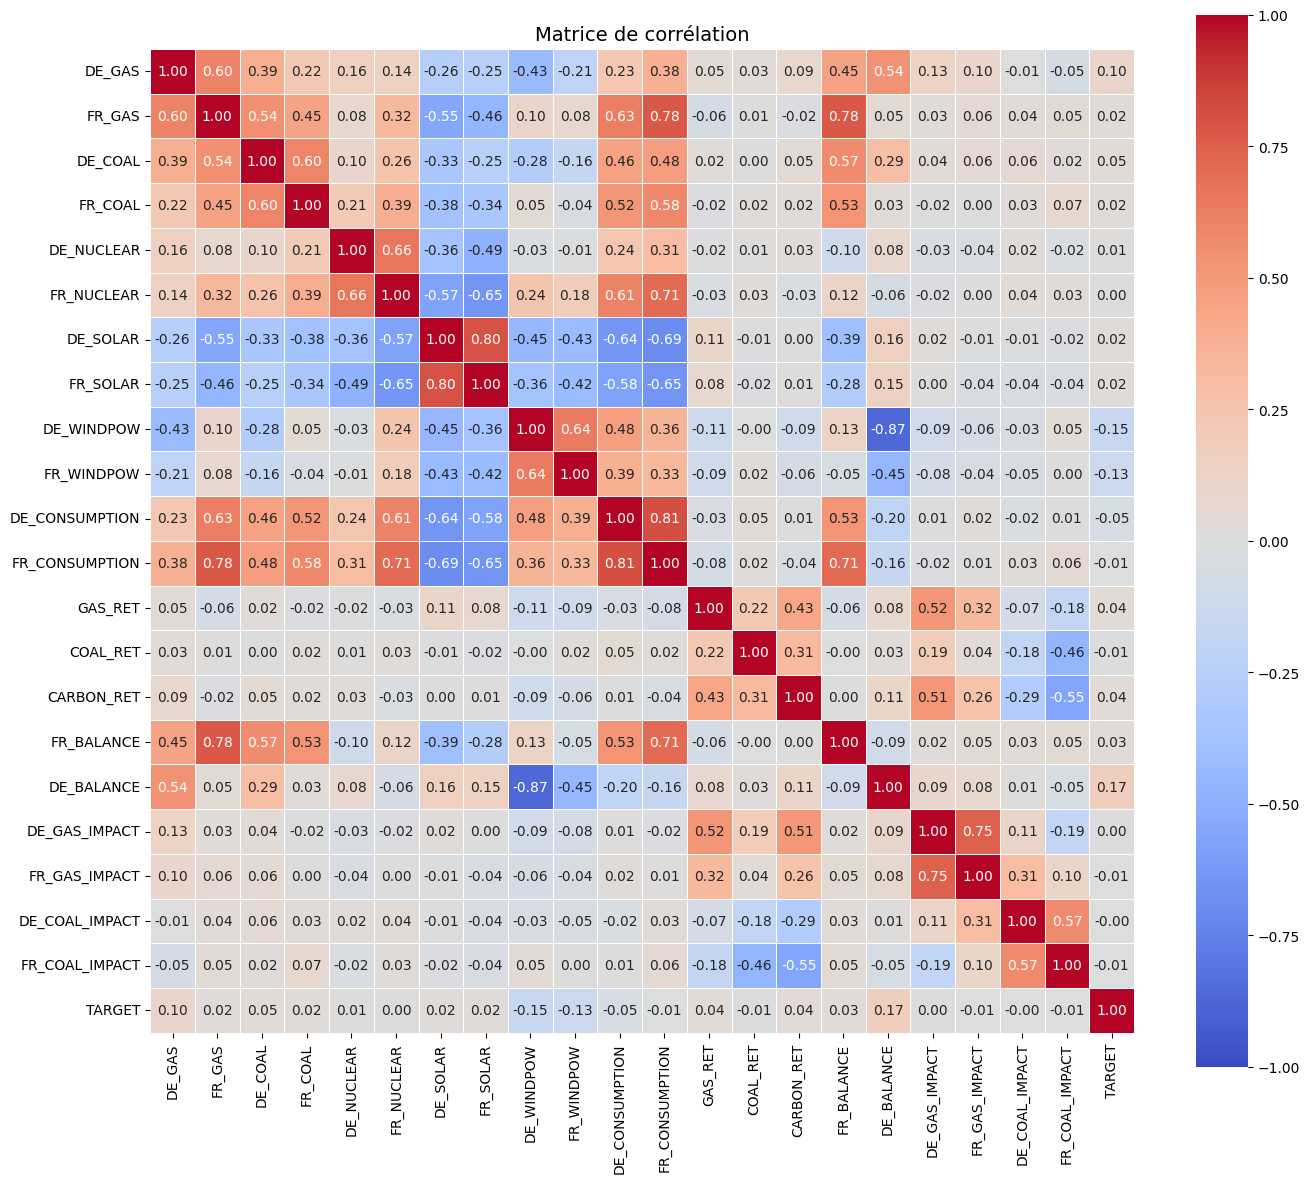

In [65]:
# Sélectionner les colonnes numériques d'intérêt
cols = columns_dict['to_keep'] + [
    'DE_GAS', 'FR_GAS', 'DE_COAL', 'FR_COAL',
    'DE_NUCLEAR', 'FR_NUCLEAR', 'DE_SOLAR', 'FR_SOLAR',
    'DE_WINDPOW', 'FR_WINDPOW',
    'DE_CONSUMPTION', 'FR_CONSUMPTION',
    'GAS_RET', 'COAL_RET', 'CARBON_RET', 'FR_BALANCE', 'DE_BALANCE',
    'DE_GAS_IMPACT', 'FR_GAS_IMPACT', 'DE_COAL_IMPACT', 'FR_COAL_IMPACT'
]

all_series = pd.merge(
    x_train_filled[cols].copy(),
    y_train[['ID', 'TARGET']],
    on='ID',
    how='inner'
)

all_series.drop(columns=columns_dict['to_keep'], inplace=True)

corr = all_series.corr()

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    corr,
    annot=True,          # affiche les valeurs
    fmt=".2f",           # 2 décimales
    cmap="coolwarm",     # rouge=positif, bleu=négatif
    center=0,            # centre la colormap sur 0
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Matrice de corrélation", fontsize=14)
plt.tight_layout()
plt.show()

## Détection des outliers

In [66]:
# Détection des outliers
def get_outliers(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR

    outliers = serie[(serie < borne_inf) | (serie > borne_sup)]
    if not len(outliers)==0:
        print(f"{serie.name}:\nNombre d'outliers : {len(outliers)}")
        #print(f"Valeurs aberrantes : {outliers.values}")

for col in x_train.drop(columns=['ID', 'DAY_ID', 'COUNTRY']).columns:
    get_outliers(x_train[col])


DE_CONSUMPTION:
Nombre d'outliers : 9
FR_CONSUMPTION:
Nombre d'outliers : 2
FR_COAL:
Nombre d'outliers : 113
DE_HYDRO:
Nombre d'outliers : 10
FR_HYDRO:
Nombre d'outliers : 28
DE_NUCLEAR:
Nombre d'outliers : 28
DE_WINDPOW:
Nombre d'outliers : 62
FR_WINDPOW:
Nombre d'outliers : 38
DE_LIGNITE:
Nombre d'outliers : 30
DE_RESIDUAL_LOAD:
Nombre d'outliers : 28
FR_RESIDUAL_LOAD:
Nombre d'outliers : 21
DE_RAIN:
Nombre d'outliers : 90
FR_RAIN:
Nombre d'outliers : 142
DE_WIND:
Nombre d'outliers : 52
FR_WIND:
Nombre d'outliers : 14
DE_TEMP:
Nombre d'outliers : 15
FR_TEMP:
Nombre d'outliers : 10
GAS_RET:
Nombre d'outliers : 36
COAL_RET:
Nombre d'outliers : 66
CARBON_RET:
Nombre d'outliers : 64


## ALL/FR/DE datasets creation 

In [67]:
# Séparation train
x_train_FR = (
    x_train_filled
    .query("COUNTRY == 'FR'")
    .reset_index(drop=True)
)

y_train_FR = (
    y_train[y_train["ID"].isin(x_train_FR["ID"])]
    .reset_index(drop=True)
)

x_train_DE = (
    x_train_filled
    .query("COUNTRY == 'DE'")
    .reset_index(drop=True)
)

y_train_DE = (
    y_train[y_train["ID"].isin(x_train_DE["ID"])]
    .reset_index(drop=True)
)

# Séparation test
x_test_FR = (
    x_test_filled
    .query("COUNTRY == 'FR'")
    .reset_index(drop=True)
)

x_test_DE = (
    x_test_filled
    .query("COUNTRY == 'DE'")
    .reset_index(drop=True)
)


In [68]:
# Jeux finaux
data_dict = {
    "ALL": (pd.merge(x_train_filled, y_train, on="ID"), x_test_filled),
    "FR": (pd.merge(x_train_FR, y_train_FR, on="ID"), x_test_FR),
    "DE": (pd.merge(x_train_DE, y_train_DE, on="ID"), x_test_DE)
}

# First Models

In [69]:
models = {
    "Linear": LinearRegression(),
    "Ridge (alpha = 1)": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1, max_iter=10000)
}

results = []

# Boucle pour voir les performances de chaque modèle sur chaque dataset
for name, data_set in data_dict.items():

    # Récupération des datas dans le dictionnaires
    data_train = data_set[0]

    # Séparation des features et de la target
    Y = data_train["TARGET"]
    X = data_train.drop(columns=["TARGET"] + columns_dict["to_keep"], errors="ignore")

    # Boucle sur les différents modèles
    for model_name, model in models.items():

        # Fit du modèle sur le train
        model.fit(X, Y)

        # Prévision du de Y avec X
        y_pred_train = model.predict(X)

        # Comparaison de Y et y_pred_train avec le coefficient de Spearman
        results.append({
            "Dataset": name,
            "Model": model_name,
            "Spearman Train": spearmanr(Y, y_pred_train).correlation,
        })

results_df = (
    pd.DataFrame(results)
    .sort_values(by="Spearman Train", ascending=False)
    .reset_index(drop=True)
)

results_df

,Dataset,Model,Spearman Train
0,DE,Ridge (alpha = 1),0.439862
1,DE,Linear,0.438597
2,DE,Lasso,0.366252
3,ALL,Ridge (alpha = 1),0.274675
4,ALL,Linear,0.273988
5,ALL,Lasso,0.216671
6,FR,Ridge (alpha = 1),0.207992
7,FR,Linear,0.202093
8,FR,Lasso,0.121530


In [70]:
data_dict["ALL"][0].to_csv(DATA_DIR + "/all_data_train_filled.csv", index=False)

# Features Research

In [75]:
data_dict['FR'][0]

,ID,DAY_ID,COUNTRY,DE_CONSUMPTION,FR_CONSUMPTION,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,FR_NET_EXPORT,DE_NET_IMPORT,...,CARBON_RET,FR_BALANCE,DE_BALANCE,MARGINAL_GAS,MARGINAL_COAL,DE_GAS_IMPACT,FR_GAS_IMPACT,DE_COAL_IMPACT,FR_COAL_IMPACT,TARGET
0,933,992,FR,0.880508,0.881603,-0.164287,0.164287,-0.306899,0.099455,0.306899,...,-0.220830,0.327568,0.114792,-0.265980,-0.371555,-0.017770,0.091700,-0.016401,0.288474,-0.174539
1,934,740,FR,0.683673,0.813651,-0.164287,0.164287,-0.306899,0.099455,0.306899,...,-0.551201,0.602627,0.213839,-0.061820,-0.525886,-0.013804,0.006023,-0.243571,0.409153,4.724418
2,935,52,FR,1.231695,1.269656,-0.164287,0.164287,-0.306899,0.099455,0.306899,...,0.270359,1.164841,0.404273,0.147642,-0.033027,0.080018,0.107208,-0.027388,0.004003,0.001284
3,936,28,FR,1.408520,1.391108,-0.164287,0.164287,-0.306899,0.099455,0.306899,...,0.787153,1.387028,0.684061,0.196492,1.095292,0.144716,0.189267,1.076439,0.358520,-0.142445
4,937,65,FR,1.075988,1.276328,-0.164287,0.164287,-0.306899,0.099455,0.306899,...,0.131572,1.292252,1.966255,-0.165069,0.409675,-0.233558,-0.184290,1.131098,0.269892,-0.100006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
846,2142,701,FR,1.032122,0.383270,0.451691,-0.451691,0.437667,-1.106814,-0.437667,...,0.362803,0.783954,-0.274043,0.537886,0.201513,0.287229,0.590169,0.184536,-0.043602,0.957628
847,2143,112,FR,0.979093,0.338229,1.138619,-1.138619,0.480707,-1.631364,-0.480707,...,1.012246,1.365382,-0.319938,0.885714,1.458091,0.391859,0.325291,1.782390,-0.342450,0.687808
848,2144,102,FR,1.009837,0.237311,-0.093751,0.093751,-0.425785,-1.194162,0.425785,...,-0.545607,0.963736,1.186650,-0.610538,-0.022381,-0.486130,-0.412235,-0.030653,0.004976,-0.083983
849,2145,414,FR,0.762955,0.151155,1.215111,-1.215111,-0.055368,-1.817169,0.055368,...,0.541685,1.907838,0.791679,0.291344,0.667407,0.307229,0.294036,1.024529,-0.177458,-0.176865


In [85]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV

selected_features_dict = {}

for name, data_set in data_dict.items():

    # Features / target
    X = data_set[0].drop(columns=['TARGET'] + columns_dict["to_keep"], errors="ignore")
    y = data_set[0]['TARGET']

    # Pipeline complet
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('elastic', ElasticNetCV(
            l1_ratio=[0.1, 0.5, 0.9, 1.0],
            alphas=np.logspace(-4, 1, 100),
            cv=5,
            random_state=42
        ))
    ])

    pipe.fit(X, y)

    # Récupérer les coefficients
    elastic = pipe.named_steps['elastic']
    coefs = pd.Series(elastic.coef_, index=X.columns)

    # Features sélectionnées
    selected_features_dict[name] = coefs[coefs != 0].index.tolist()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.22477740697240733, tolerance: 0.12738377141947466
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.7229608272750738, tolerance: 0.12738377141947466
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.1110027779789107, tolerance: 0.12738377141947466
  model = cd_fast.ene

In [86]:
for name, features in selected_features_dict.items():
    print(f"Features sélectionnées pour {name} : {features}")

Features sélectionnées pour ALL : ['DE_FR_EXCHANGE', 'FR_DE_EXCHANGE', 'DE_NET_EXPORT', 'DE_NET_IMPORT', 'DE_HYDRO', 'FR_HYDRO', 'DE_WINDPOW', 'FR_WINDPOW', 'DE_RESIDUAL_LOAD', 'FR_RESIDUAL_LOAD', 'FR_BALANCE', 'DE_BALANCE', 'MARGINAL_GAS']
Features sélectionnées pour FR : []
Features sélectionnées pour DE : ['FR_WINDPOW', 'DE_BALANCE']
